<a href="https://colab.research.google.com/github/sharvmahajan/TE/blob/DSBDAL/A9/DSBDAL_Assignment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DSBDAL Assignment 9

Name : Sharv Mahajan

Roll No. : 31430

### Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

###Load Dataset

In [2]:
dataset = pd.read_csv("Social_Network_Ads.csv")
display(dataset.head())

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


### Age vs Salary

Distribution of users based on Age and Estimated Salary.

Red points = Not Purchased
Green points = Purchased

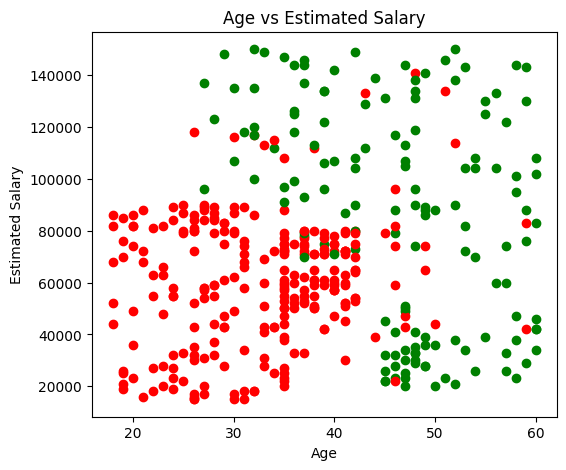

In [3]:
plt.figure(figsize=(6,5))

for i in range(len(dataset)):
    if dataset['Purchased'][i] == 0:
        plt.scatter(dataset['Age'][i], dataset['EstimatedSalary'][i], color='red')
    else:
        plt.scatter(dataset['Age'][i], dataset['EstimatedSalary'][i], color='green')

plt.title("Age vs Estimated Salary")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.show()

### Select features and target

Select independent variables (Age, EstimatedSalary)

Select dependent variable (Purchased)

In [4]:
X = dataset[['Age', 'EstimatedSalary']]

y = dataset['Purchased']

display(X.head())
display(y.head())

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000


,Purchased
0,0
1,0
2,0
3,0
4,0


### Split dataset

Split dataset into Training set and Testing set.

Training data is used to train model.

Testing data is used to evaluate model.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=0
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (300, 2)
Testing size: (100, 2)


### Feature Scaling

Feature scaling is required because values have different ranges.

StandardScaler converts values to same scale.

In [6]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### Train Logistic Regression

Train Logistic Regression model using training data.

In [7]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

### Training Result Visualization


This plot shows how Logistic Regression separates Purchased and Not Purchased users.

Decision boundary line separates two classes.

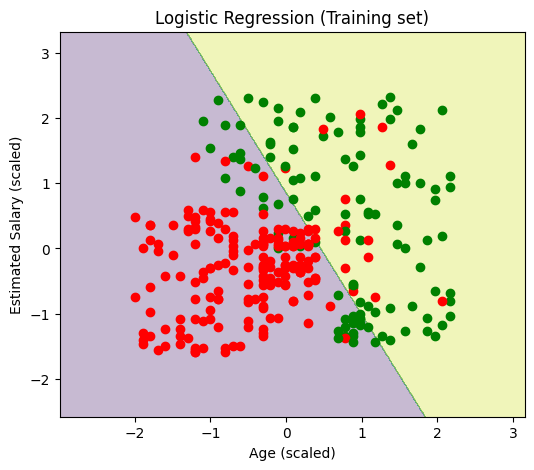

In [8]:
from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(X_set[:,0].min()-1, X_set[:,0].max()+1, 0.01),
    np.arange(X_set[:,1].min()-1, X_set[:,1].max()+1, 0.01)
)

plt.figure(figsize=(6,5))

plt.contourf(
    X1, X2,
    model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.3
)

for i in range(len(X_set)):
    if y_set.iloc[i] == 0:
        plt.scatter(X_set[i,0], X_set[i,1], color='red')
    else:
        plt.scatter(X_set[i,0], X_set[i,1], color='green')

plt.title("Logistic Regression (Training set)")
plt.xlabel("Age (scaled)")
plt.ylabel("Estimated Salary (scaled)")
plt.show()

### Prediction

Use trained model to predict test data.

In [9]:
y_pred = model.predict(X_test)

print("Predicted values:")
print(y_pred)

print("Actual values:")
print(y_test.values)

Predicted values:
[0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0
 0 0 1 0 1 1 1 1 0 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1]
Actual values:
[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 1 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 1 1 1 0 0 0 1 1 0 1 1 0 0 1 0 0 0 1 0 1 1 1]


### Confusion Matrix

Confusion Matrix shows model performance.

It contains:

*   TP – True Positive
*   TN – True Negative
*   FP – False Positive
*   FN – False Negative





In [10]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[65  3]
 [ 8 24]]


### Calculate TP, TN, FP, FN

In [11]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

TP: 24
TN: 65
FP: 3
FN: 8


### Performance metrics

Calculate Accuracy, Error Rate, Precision, Recall using formulas.

In [12]:
accuracy = (TP + TN) / (TP + TN + FP + FN)

error_rate = (FP + FN) / (TP + TN + FP + FN)

precision = TP / (TP + FP)

recall = TP / (TP + FN)

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.89
Error Rate: 0.11
Precision: 0.8888888888888888
Recall: 0.75


**Analysis of Logistic Regression Model Performance:**

1. **Accuracy = 0.89** (89%)

    This means the model correctly predicted 89% of the total users.
    It shows the model performs well overall.

2. **Error Rate = 0.11** (11%)

    This means 11% of the predictions are incorrect.
    Lower error rate indicates better model performance.

3. **Precision = 0.8889** (88.89%)

    Precision indicates how many predicted "Purchased" users actually purchased.
    Out of all users predicted as Purchased, 88.89% were correct.
    This shows the model makes reliable positive predictions.

4. **Recall = 0.75** (75%)

    Recall indicates how many actual Purchased users were correctly identified.
    The model correctly identified 75% of actual buyers.
    This means some buyers were missed by the model.

**Conclusion:**
The Logistic Regression model performs well with high accuracy and precision.
However, recall is slightly lower, which means the model misses some actual buyers.
Overall, the model is effective and suitable for classification.